C:\Users\DELL.CC\AppData\Local\Temp\ipykernel_9172\1266188971.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.index, y=city_sales.values, palette='viridis', ax=axes[0,0])
C:\Users\DELL.CC\AppData\Local\Temp\ipykernel_9172\1266188971.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_sales.index, y=product_sales.values, palette='magma', ax=axes[0,1])
C:\Users\DELL.CC\AppData\Local\Temp\ipykernel_9172\1266188971.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_sales.index, y=gender_sales.values, palet

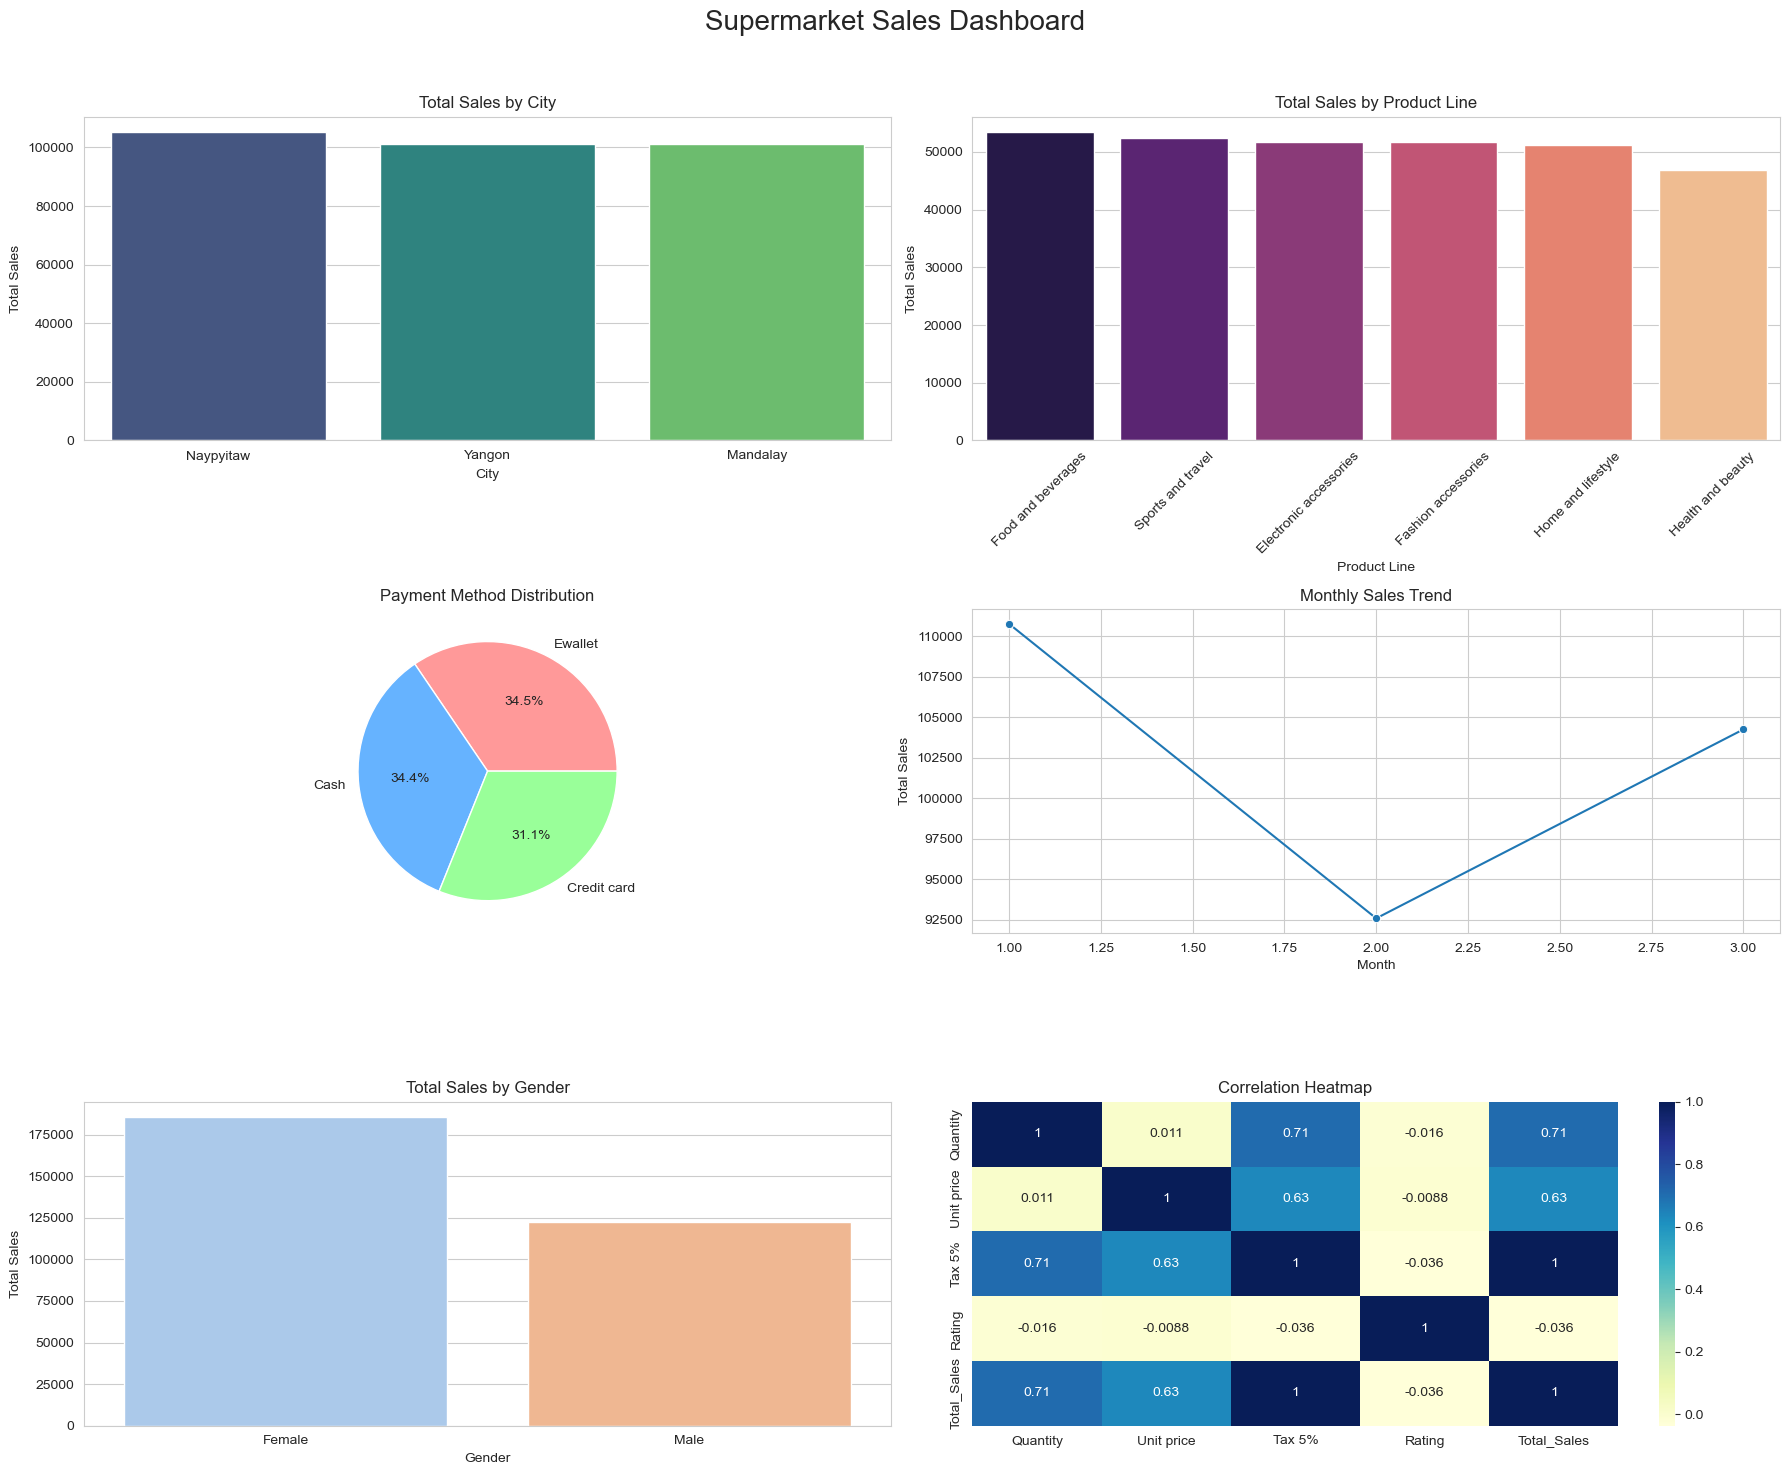

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\DELL.CC\Desktop\SuperMarket Analysis.csv")

# Preprocessing
df['Total_Sales'] = df['Unit price'] * df['Quantity']
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(18,15))
fig.suptitle('Supermarket Sales Dashboard', fontsize=20)

# 1️⃣ Total Sales by City
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)
sns.barplot(x=city_sales.index, y=city_sales.values, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Total Sales by City')
axes[0,0].set_ylabel('Total Sales')
axes[0,0].set_xlabel('City')

# 2️⃣ Total Sales by Product Line
product_sales = df.groupby('Product line')['Total_Sales'].sum().sort_values(ascending=False)
sns.barplot(x=product_sales.index, y=product_sales.values, palette='magma', ax=axes[0,1])
axes[0,1].set_title('Total Sales by Product Line')
axes[0,1].set_ylabel('Total Sales')
axes[0,1].set_xlabel('Product Line')
axes[0,1].tick_params(axis='x', rotation=45)

# 3️⃣ Payment Method Distribution
payment_counts = df['Payment'].value_counts()
axes[1,0].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
axes[1,0].set_title('Payment Method Distribution')

# 4️⃣ Monthly Sales Trend
monthly_sales = df.groupby('Month')['Total_Sales'].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', ax=axes[1,1])
axes[1,1].set_title('Monthly Sales Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Total Sales')

# 5️⃣ Sales by Gender
gender_sales = df.groupby('Gender')['Total_Sales'].sum()
sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='pastel', ax=axes[2,0])
axes[2,0].set_title('Total Sales by Gender')
axes[2,0].set_xlabel('Gender')
axes[2,0].set_ylabel('Total Sales')

# 6️⃣ Correlation Heatmap
numeric_cols = ['Quantity', 'Unit price', 'Tax 5%', 'Rating', 'Total_Sales']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', ax=axes[2,1])
axes[2,1].set_title('Correlation Heatmap')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()